## 🤖 Auswahl des Machine-Learning-Algorithmus

Zur Lösung der Problemstellung wurde ein **überwachtes Klassifikationsmodell** eingesetzt,  
da das Ziel darin besteht, anhand **vor dem Rennen bekannter Merkmale** vorherzusagen,  
ob ein Fahrer eine **Top-10-Platzierung** erreicht oder nicht.

---

### 🧠 Primärer Algorithmus: **Logistische Regression**

#### 📝 Begründung der Modellwahl:
- ✅ Etabliertes **Baseline-Modell** für binäre Klassifikationsprobleme  
- 📊 Besonders geeignet für **strukturierte tabellarische Daten**  
- 🔍 **Gut interpretierbar** – Einfluss einzelner Merkmale über Modellkoeffizienten nachvollziehbar  
- ⚙️ **Geringe Rechenkomplexität** → stabile & reproduzierbare Ergebnisse

---

### 🌳 Ergänzend: **Random-Forest-Klassifikator**

Ein **Random Forest** wurde zusätzlich trainiert, um einen **leistungsstärkeren, nicht-linearen Ansatz** zum Vergleich heranzuziehen.  
Dadurch konnte überprüft werden, ob **komplexere Zusammenhänge** die **Vorhersageleistung verbessern**.


In [1]:
import pandas as pd
import numpy as np


In [2]:
feature_df = pd.read_csv("../data/processed/driver_race_features.csv")
print(feature_df.shape)
feature_df.head()


(25121, 17)


,season,round,raceId,race_date,driverId,driver_name,constructorId,constructor_name,circuitId,circuit_name,grid,driver_experience,driver_recent_form,constructor_strength,era,grid_bucket,target_top10
0,1950,1,833,1950-05-13,579,Juan Fangio,51,Alfa Romeo,9,Silverstone Circuit,3,0,11.754182,11.823009,1950-1969,front_row_1_3,0
1,1950,1,833,1950-05-13,589,Louis Chiron,105,Maserati,9,Silverstone Circuit,11,0,11.754182,11.823009,1950-1969,mid_11_20,0
2,1950,1,833,1950-05-13,619,Bob Gerard,151,ERA,9,Silverstone Circuit,13,0,11.754182,11.823009,1950-1969,mid_11_20,1
3,1950,1,833,1950-05-13,627,Louis Rosier,154,Talbot-Lago,9,Silverstone Circuit,9,0,11.754182,11.823009,1950-1969,top10_4_10,1
4,1950,1,833,1950-05-13,640,Toulo de Graffenried,105,Maserati,9,Silverstone Circuit,8,0,11.754182,18.000000,1950-1969,top10_4_10,0


## 🗺️ Holdout: letztes Rennen ausklammern

Wir halten das zeitlich letzte Rennen im Datensatz als **Holdout** zurück, um zu sehen, wie gut das Modell auf ein tatsächlich unbekanntes Event **generalisiert**. Ein Holdout bleibt **komplett außerhalb des Trainings**: Wir filtern das **jüngste Rennen (per Datum)**, sichern diese Zeilen separat und trainieren auf dem Rest. So vermeiden wir, dass das Modell Ergebnisse kennt, die es eigentlich vorhersagen soll, und können später die Prognosen mit dem realen Ausgang vergleichen.

Die Daten sind **chronologisch sortiert**, daher ist es sinnvoll, ein Rennen aus der **Zukunftsperspektive** des Modells zu testen. Ein **vergangenes Rennen** als Holdout wäre weniger aussagekräftig, weil das Modell bei **zeitlicher Durchmischung** indirekt Information darüber lernen könnte (**Data Leakage**) und die Generalisierung **überschätzt** würde.


Wir kommen später auf **Marina Circuit** zurück, um die Vorhersagen gegen das **reale Ergebnis** zu spiegeln.

> 🧠 Ein **Holdout** ist ein bewusst zurückgehaltener Datensatz, der **nicht zum Trainieren** verwendet wird. Man trainiert das Modell auf dem übrigen Teil der Daten und prüft es erst danach auf dem Holdout. So sieht man, wie gut das Modell auf **wirklich unbekannte Fälle** generalisiert und ob es **überfittet**. Oft ist der Holdout ein **bestimmter Zeitraum**, eine **Kundengruppe** oder ein **zufällig abgetrennter Teil** der Daten.




In [3]:
# Identify the latest race by date
feature_df["race_date_parsed"] = pd.to_datetime(feature_df["race_date"], errors="coerce")
latest = feature_df.sort_values("race_date_parsed").iloc[-1]

HOLDOUT_SEASON = int(latest["season"])
HOLDOUT_ROUND = int(latest["round"])
HOLDOUT_CIRCUIT_ID = latest["circuitId"]
HOLDOUT_RACEID = latest.get("raceId")
HOLDOUT_CIRCUIT_NAME = latest.get("circuit_name", "")

mask_holdout = (
    (feature_df["season"] == HOLDOUT_SEASON)
    & (feature_df["round"] == HOLDOUT_ROUND)
    & (feature_df["circuitId"].astype(str) == str(HOLDOUT_CIRCUIT_ID))
)

holdout_df = feature_df[mask_holdout].copy()
feature_df_train = feature_df[~mask_holdout].copy()

print("Holdout race:", HOLDOUT_SEASON, HOLDOUT_ROUND, HOLDOUT_CIRCUIT_ID, HOLDOUT_CIRCUIT_NAME)
print("Holdout rows:", holdout_df.shape)
print("Training rows:", feature_df_train.shape)

holdout_path = "../data/processed/holdout_latest_race.csv"
holdout_df.to_csv(holdout_path, index=False)
print("Saved holdout to", holdout_path)

# Clean up helper column if desired
feature_df.drop(columns=["race_date_parsed"], inplace=True)


Holdout race: 2024 24 24 Yas Marina Circuit
Holdout rows: (20, 18)
Training rows: (25101, 18)
Saved holdout to ../data/processed/holdout_latest_race.csv


In [4]:
y = feature_df_train["target_top10"]

X = feature_df_train.drop(columns=[
    "target_top10",
    "race_date",       
    "driver_name",
    "constructor_name",
    "circuit_name"
])

X = X.drop(columns=["raceId"], errors="ignore")

print(X.shape, y.shape)


(25101, 12) (25101,)


## 🧪 Vorbereitung der Daten für das Training

Für das Modelltraining wurden **ausschließlich Pre-Race-Features** verwendet – also Merkmale,  
die **vor Rennbeginn bekannt** sind, um **Datenleckagen (Data Leakage)** zu vermeiden.

---

### 🧾 Die Feature-Matrix enthielt unter anderem:

- 🏁 **Startposition (Grid)** und **Grid-Kategorien**  
- 🧑‍✈️ **Fahrer-Erfahrung** (Anzahl vorheriger Rennen)  
- 📈 **Aktuelle Fahrerform** (rollierender Mittelwert vorheriger Ergebnisse)  
- 🛠️ **Teamstärke** (historische durchschnittliche Platzierungen)  
- 🗺️ **Strecke** und **Epoche** (kategorisch)

---

### ⚙️ Vorverarbeitungsschritte:

- 📊 **Numerische Merkmale** wurden **standardisiert**,  
  um unterschiedliche Wertebereiche auszugleichen  
- 🔤 **Kategorische Merkmale** wurden mittels **One-Hot-Encoding**  
  in numerische Repräsentationen überführt  
- 🧱 Alle Schritte wurden in einer **Pipeline** zusammengefasst,  
  um eine **konsistente und korrekte Anwendung** während jeder Trainingsiteration zu gewährleisten



In [5]:
cat_cols = ["circuitId", "era", "grid_bucket"]

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Encoded:", X_encoded.shape)


Encoded: (25101, 92)


In [6]:
print(y.value_counts())
print(y.value_counts(normalize=True))


target_top10
0    13804
1    11297
Name: count, dtype: int64
target_top10
0    0.549938
1    0.450062
Name: proportion, dtype: float64


In [7]:
X_encoded.dtypes.value_counts()


bool              83
int64              6
float64            2
datetime64[ns]     1
Name: count, dtype: int64

In [ ]:
dt_cols = X_encoded.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns
print("Datetime cols in X_encoded:", list(dt_cols))
X_encoded = X_encoded.drop(columns=dt_cols)

In [8]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

num_cols = ["grid", "driver_experience", "driver_recent_form", "constructor_strength", "round", "season"]
num_cols = [c for c in num_cols if c in X_encoded.columns]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
    ],
    remainder="passthrough"
)

logreg = LogisticRegression(max_iter=5000, solver="lbfgs")

pipeline_lr = Pipeline([
    ("preprocess", preprocess),
    ("model", logreg)
])

cv = TimeSeriesSplit(n_splits=5)

scoring = ["accuracy", "precision", "recall", "f1"]

scores_lr = cross_validate(
    pipeline_lr,
    X_encoded,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision"   # PR-AUC
    ],
    n_jobs=-1,
    error_score="raise"
)

for m in scoring:
    vals = scores_lr[f"test_{m}"]
    print(f"LogReg {m}: mean={vals.mean():.3f}, std={vals.std():.3f}")


TypeError: float() argument must be a string or a real number, not 'Timestamp'

you can't predict something by training on future data and testing on past 
as long as you have chronology you can't use kfold cv 
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html 

Instead of Random forrest: https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html#lightgbm.LGBMClassifier

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import cross_validate, TimeSeriesSplit

# LightGBM classifier
lgbm = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    class_weight='balanced'
)

# Stratified CV (uses existing cv)
scores_lgbm = cross_validate(
    lgbm,
    X_encoded,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision"
    ],
    n_jobs=-1,
    error_score="raise",
)

for m in scoring:
    vals = scores_lgbm[f"test_{m}"]
    print(f"LGBM (Stratified) {m}: mean={vals.mean():.3f}, std={vals.std():.3f}")

# Time-aware CV
tscv = TimeSeriesSplit(n_splits=5)
scores_lgbm_ts = cross_validate(
    lgbm,
    X_encoded,
    y,
    cv=tscv,
    scoring=scoring,
    n_jobs=-1,
    error_score="raise",
)

for m in scoring:
    vals = scores_lgbm_ts[f"test_{m}"]
    print(f"LGBM (TimeSeriesSplit) {m}: mean={vals.mean():.3f}, std={vals.std():.3f}")


[LightGBM] [Info] Number of positive: 3790, number of negative: 4579
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000863 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1150
[LightGBM] [Info] Number of data points in the train set: 8369, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 7290, number of negative: 9445
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000696 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1323
[LightGBM] [Info] Number of data points in the train set: 16735, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] N

In [ ]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy_mean": scores_lr["test_accuracy"].mean(),
        "Precision_mean": scores_lr["test_precision"].mean(),
        "Recall_mean": scores_lr["test_recall"].mean(),
        "F1_mean": scores_lr["test_f1"].mean(),
        "Accuracy_std": scores_lr["test_accuracy"].std(),
        "Precision_std": scores_lr["test_precision"].std(),
        "Recall_std": scores_lr["test_recall"].std(),
        "F1_std": scores_lr["test_f1"].std(),
    },
    {
        "Model": "LightGBM",
        "Accuracy_mean": scores_lgbm["test_accuracy"].mean(),
        "Precision_mean": scores_lgbm["test_precision"].mean(),
        "Recall_mean": scores_lgbm["test_recall"].mean(),
        "F1_mean": scores_lgbm["test_f1"].mean(),
        "Accuracy_std": scores_lgbm["test_accuracy"].std(),
        "Precision_std": scores_lgbm["test_precision"].std(),
        "Recall_std": scores_lgbm["test_recall"].std(),
        "F1_std": scores_lgbm["test_f1"].std(),
    }
])

comparison


,Model,Accuracy_mean,Precision_mean,Recall_mean,F1_mean,Accuracy_std,Precision_std,Recall_std,F1_std
0,Logistic Regression,0.668994,0.647154,0.559509,0.592453,0.044262,0.095058,0.102665,0.081707
1,LightGBM,0.641740,0.580290,0.519384,0.535077,0.054254,0.090218,0.209701,0.162448


roc auc, roc pr instead of these 
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
set a threshold for metrics (like > 0.5)

### Modellvergleich und Auswahl des finalen Modells


Text(0.5, 1.0, 'Model comparison across evaluation metrics')

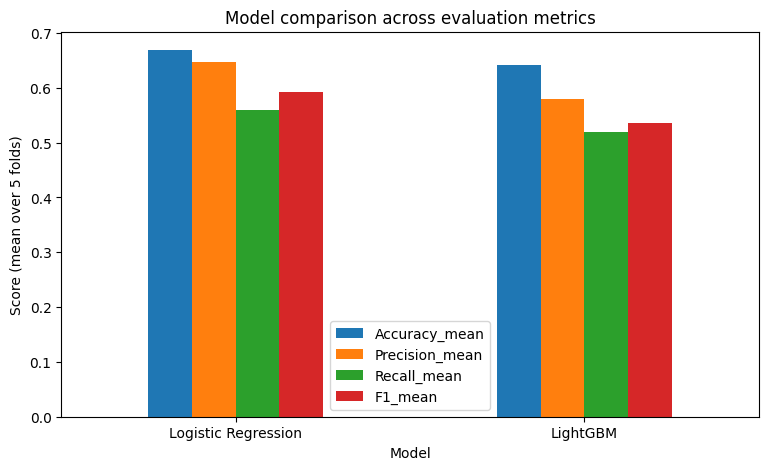

In [ ]:
ax = comparison.set_index("Model")[
    ["Accuracy_mean", "Precision_mean", "Recall_mean", "F1_mean"]
].plot.bar(rot=0, figsize=(9,5))

ax.set_ylabel("Score (mean over 5 folds)")
ax.set_title("Model comparison across evaluation metrics")

## ✅ Auswahl des finalen Modells

Die **logistische Regression** erzielte den **höchsten F1-Score**  
und zeigte **stabile Ergebnisse über alle Folds** hinweg.

---

### 🔍 Weitere Vorteile:
- Bessere **Interpretierbarkeit** der Einflussfaktoren  
  durch Analyse der **Modellkoeffizienten**

---

Aufgrund dieser Ergebnisse wurde die **logistische Regression**  
als **finales Modell ausgewählt** und anschließend auf dem **vollständigen Datensatz trainiert**.


In [ ]:
pipeline_lr.fit(X_encoded, y)

print("Final model (Logistic Regression) trained on full dataset.")

Final model (Logistic Regression) trained on full dataset.


In [ ]:
import joblib

joblib.dump(pipeline_lr, "../data/processed/final_model_logreg.joblib")

print("Final Logistic Regression model saved to data/processed/final_model_logreg.joblib")


Final Logistic Regression model saved to data/processed/final_model_logreg.joblib


In [ ]:
model = pipeline_lr.named_steps["model"]

coef_series = (
    pd.Series(model.coef_[0], index=X_encoded.columns)
      .sort_values()
)

print("Stärkste negative Koeffizienten (senken Top-10-Wahrscheinlichkeit):")
print(coef_series.head(15))

print("\nStärkste positive Koeffizienten (erhöhen Top-10-Wahrscheinlichkeit):")
print(coef_series.tail(15))

Stärkste negative Koeffizienten (senken Top-10-Wahrscheinlichkeit):
season                  -0.759652
era_1990-2009           -0.552084
era_1970-1989           -0.515262
era_2010-2021           -0.311169
circuitId_64            -0.218419
grid_bucket_mid_11_20   -0.196575
era_2022+               -0.178516
circuitId_58            -0.167824
circuitId_19            -0.149719
circuitId_35            -0.141895
circuitId_60            -0.118757
driverId                -0.110023
circuitId_67            -0.109120
circuitId_68            -0.103815
circuitId_12            -0.096878
dtype: float64

Stärkste positive Koeffizienten (erhöhen Top-10-Wahrscheinlichkeit):
circuitId_62    0.069249
circuitId_76    0.078598
circuitId_6     0.084188
circuitId_53    0.092801
circuitId_45    0.102181
circuitId_75    0.122145
circuitId_52    0.126988
circuitId_61    0.131476
circuitId_65    0.141004
circuitId_54    0.166153
round           0.174341
circuitId_25    0.223168
circuitId_49    0.225895
circuitId_51

## 🏁 Ergebnis des Modelltrainings

Das **finale Modell** lernt eine **Abbildung von vor dem Rennen bekannten Merkmalen**  
auf die **Wahrscheinlichkeit einer Top-10-Platzierung**.

---

Durch den Einsatz von **Kreuzvalidierung** konnte gezeigt werden,  
dass das Modell auch auf **unbekannten Daten zuverlässig generalisiert**.

✅ Das Modell ist somit geeignet für **realistische Vorhersagen vor dem Rennstart**.
